# PROYECTO FINAL APRENDIZAJE SUPERVISADO 2



# Datos del alumno

**Nombre**: Adrián


**Apellidos**: Robles Arques


**Grupo:** A1

FASE 4
---------------------------------

# Preparación del Proyecto

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [3]:
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             roc_auc_score,
                             roc_curve,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             classification_report)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     learning_curve,
                                     validation_curve,
                                     train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample
from warnings import filterwarnings

In [4]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

In [58]:
#Definimos función para crear la curva ROC
def plot_roc_curve(y_test, y_train, y_pred_test, y_pred_train, p = 2):
  fpr_test, tpr_test, thresholds = roc_curve(y_test, y_pred_test)
  roc_auc_test = roc_auc_score(y_test, y_pred_test)

  fpr_train, tpr_train, thresholds = roc_curve(y_train, y_pred_train)
  roc_auc_train = roc_auc_score(y_train, y_pred_train)

  plt.figure()
  plt.plot(fpr_test, tpr_test, color='darkorange', lw=1, label='Curva ROC test (AUC = {})'.format(round(roc_auc_test,p)))
  plt.plot(fpr_train, tpr_train, color='navy', lw=1, label='Curva ROC train (AUC = {})'.format(round(roc_auc_train,p)))
  plt.legend(loc="lower right")
  plt.plot([0, 1], [0, 1], color='yellow', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('Tasa de falso positivo')
  plt.ylabel('Tasa de auténtico positivo')
  plt.title('Curva ROC')

  return roc_auc_test, roc_auc_train

In [10]:
#Cargamos los datos desde local (No Google Colab)

X_test = np.load(r"C:\Users\Usuario\Desktop\Master Ciencia de Datos\Proyectos\DataScienceIEBS\Bloque 3\Aprendizaje supervisado 2\Sprint 2\X_test.npy")
X_train = np.load(r"C:\Users\Usuario\Desktop\Master Ciencia de Datos\Proyectos\DataScienceIEBS\Bloque 3\Aprendizaje supervisado 2\Sprint 2\X_train.npy")
y_test = np.load(r"C:\Users\Usuario\Desktop\Master Ciencia de Datos\Proyectos\DataScienceIEBS\Bloque 3\Aprendizaje supervisado 2\Sprint 2\y_test.npy")
y_train = np.load(r"C:\Users\Usuario\Desktop\Master Ciencia de Datos\Proyectos\DataScienceIEBS\Bloque 3\Aprendizaje supervisado 2\Sprint 2\y_train.npy")

In [7]:
from google.colab import files

ModuleNotFoundError: No module named 'google'

In [ ]:
#Cargamos desde local los datos previos

uploaded = {}
uploaded = files.upload()
X_train = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
X_test = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
y_train = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
y_test = np.load(list(uploaded.keys())[0])

NameError: name 'files' is not defined

In [11]:
#X_train, X_test,y_train,y_test = np.load("X_train.npy"),np.load("X_test.npy"),np.load("y_train.npy"),np.load("y_test.npy")

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(11999, 18)
(3000, 18)
(11999,)
(3000,)


In [28]:
#Cargamos nombre de las columnas (No Google Colab)
columnas = open(r"C:\Users\Usuario\Desktop\Master Ciencia de Datos\Proyectos\DataScienceIEBS\Bloque 3\Aprendizaje supervisado 2\Sprint 2\nom_columnas.txt")
nom_columnas = columnas.read().split("\n")
columnas.close()

# Mostramos las columnas cargadas
print(nom_columnas, len(nom_columnas))

['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'salary', 'dep_IT', 'dep_RandD', 'dep_accounting', 'dep_hr', 'dep_management', 'dep_marketing', 'dep_product_mng', 'dep_sales', 'dep_support', 'dep_technical', ''] 20


In [62]:
#Cargar datos de las columnas desde PC
uploaded = {}
uploaded = files.upload()
columnas = uploaded[list(uploaded.keys())[0]]

Saving nom_columnas.txt to nom_columnas (1).txt


In [29]:
#Generando la lista de nombres de columnas
#nom_columnas = columnas.decode('utf-8').split('\n')
nom_columnas = nom_columnas[:-1] #Aparece un espacio al final
left_ind = nom_columnas.index('left')

#Eliminamos left, dado que es la variable objetivo
nom_columnas = nom_columnas[:left_ind] + nom_columnas[left_ind+1:]
nom_columnas

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years',
 'salary',
 'dep_IT',
 'dep_RandD',
 'dep_accounting',
 'dep_hr',
 'dep_management',
 'dep_marketing',
 'dep_product_mng',
 'dep_sales',
 'dep_support',
 'dep_technical']

De acuerdo con lo estudiado en la fase anterior, durante el tercer sprint, todos los modelos coincidían en que las 5 variables más importantes, que juntas sumaban más de 0.9 del total de pesos son: satisfaction_level, time_spend_company, number_project, average_montly_hours,
last_evaluation.

De modo que vamos a proceder a tomar únicamente estas variables explicativas como método de reducción de dimensionalidad, tomando así menos datos de entrada para facilitar el entrenamiento de modelos más complejos. Estas se corresponden con las primeras 5 columnas de los datos.

In [30]:
#Tomar las primeras cinco columnas de los datos de test y train
X_train_red = X_train[:,:5]
X_test_red = X_test[:,:5]

X_train_red.shape, X_test_red.shape

((11999, 5), (3000, 5))

# Implementación del modelo

En el tercer sprint el mejor resultado lo obtuvimos en el modelo de Gradient Boost Clasiffier, vamos a probar a entrenar nuevamente ese modelo pero ahora con tan solo las 5 variables explicativas que consideramos esenciales para el modelo, empleando los mismos hiperparámetros.

In [31]:
#Instanciamos el modelo GradientBoosClasifier
GBC = GradientBoostingClassifier(
    loss= 'log_loss',
    learning_rate= 0.1,
    max_leaf_nodes= None,
    max_depth= 5,
    min_samples_leaf= 25,
    max_features= 'sqrt',
    subsample= 0.8,
    random_state= 42)

In [32]:
# Entrenamos el modelo con los datos de entrenamiento
GBC.fit(X_train_red, y_train)

GradientBoostingClassifier(max_depth=5, max_features='sqrt',
                           min_samples_leaf=25, random_state=42, subsample=0.8)

In [67]:
# Obtenemos las predicciones para el conjunto de test
Y_pred = GBC.predict(X_test_red)
Y_pred_p = GBC.predict_proba(X_test_red)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train = GBC.predict(X_train_red)
Y_pred_train_p = GBC.predict_proba(X_train_red)[:,1]

<Figure size 1000x1000 with 0 Axes>

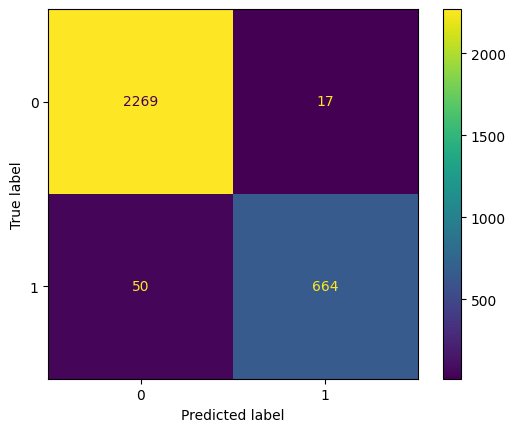

              precision    recall  f1-score   support

           0      0.978     0.993     0.985      2286
           1      0.975     0.930     0.952       714

    accuracy                          0.978      3000
   macro avg      0.977     0.961     0.969      3000
weighted avg      0.978     0.978     0.977      3000



In [68]:
# Evaluar la capacidad predictiva del modelo
cm_GBC = confusion_matrix(y_test, Y_pred)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_GBC)
ax.plot()
plt.show()

report = classification_report(y_test, Y_pred, digits = 3)
print(report)

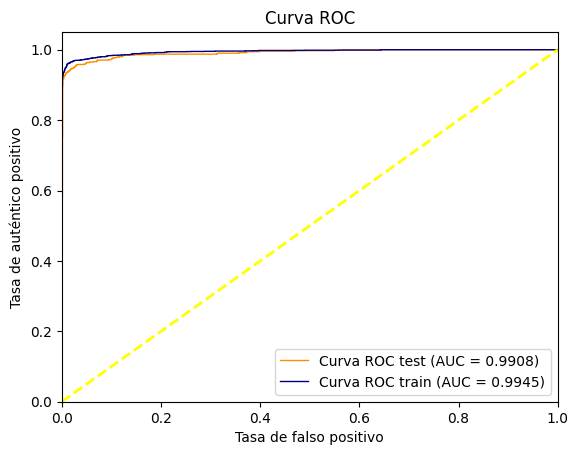

In [69]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test, AUC_train = plot_roc_curve(y_test, y_train, Y_pred_p, Y_pred_train_p, p=4)

## Evaluación del modelo

Podemos apreciar una mejora en los resultados del modelo para los parámetros de f1 score, reduciendo significativamente los falsos positivos, así como un aumento del área bajo la curva.

En el caso anterior obteníamos un f1-score:

*   f1-score 1 =  0.95
*   f1-score 0 =  0.98478

Mientras que ahora tenemos:

*   f1-score 1 = 0.952
*   f1-score 0 = 0.985

Por otra parte el área bajo la curva era:

*   AUC test = 0.9896
*   AUC train = 0.9938

Y el nuevo resultado no baja de 0.99 en ningún caso:

*   AUC test = 0.9908
*   AUC train = 0.9945

Aunque la mejora no parezca especialmente relevante por los resultados numéricos, el resultado previo ya era bastante bueno y este obtiene incluso mayor poder predictivo reduciendo la dimension de la matriz de variables explicativas de 18 a 5, con la consecuente mejora en la optimización de tiempo de computación y reducción del tiempo de entrenamiento y uso del modelo que ello implica.










## Mejora del modelo con HistBoostClassifier

Vamos a tratar de mejorar los resultados con el modelo HistBoosClassifier, que está recomendado para grupos de datos con n>10000 como es el caso. Este modelo permite acelerar el entrenamiento mediante procesamiento multicore y método de binning.

In [70]:
#Inicializamos el HistGradientBoosClassifier
HGBC = HistGradientBoostingClassifier(
    loss= 'log_loss',
    learning_rate= 0.1,
    max_leaf_nodes= None,
    max_depth= 5,
    min_samples_leaf= 25,
    max_features= 0.4,
    random_state= 42)

In [71]:
# Entrenamos el modelo con los datos de entrenamiento
HGBC.fit(X_train_red, y_train)

HistGradientBoostingClassifier(max_depth=5, max_features=0.4,
                               max_leaf_nodes=None, min_samples_leaf=25,
                               random_state=42)

In [72]:
# Obtenemos las predicciones para el conjunto de test
Y_pred2 = HGBC.predict(X_test_red)
Y_pred_p2 = HGBC.predict_proba(X_test_red)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train2 = HGBC.predict(X_train_red)
Y_pred_train_p2 = HGBC.predict_proba(X_train_red)[:,1]

<Figure size 1000x1000 with 0 Axes>

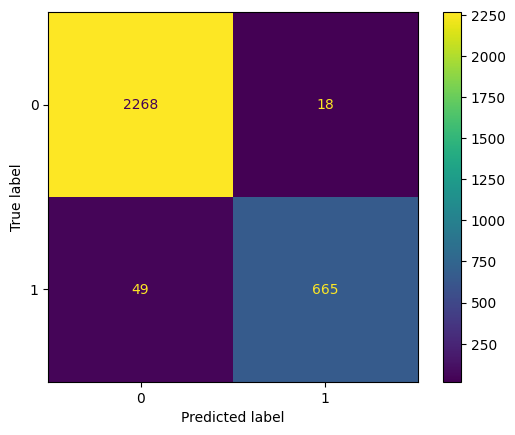

              precision    recall  f1-score   support

           0      0.979     0.992     0.985      2286
           1      0.974     0.931     0.952       714

    accuracy                          0.978      3000
   macro avg      0.976     0.962     0.969      3000
weighted avg      0.978     0.978     0.977      3000



In [73]:
# Evaluar la capacidad predictiva del modelo
cm_HGBC = confusion_matrix(y_test, Y_pred2)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_HGBC)
ax.plot()
plt.show()

report2 = classification_report(y_test, Y_pred2, digits = 3)
print(report2)

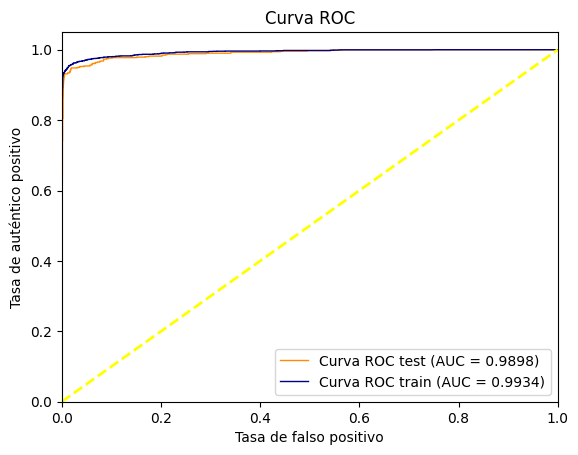

In [74]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test, AUC_train = plot_roc_curve(y_test, y_train, Y_pred_p2, Y_pred_train_p2, p=4)

In [75]:
#Vamos a guardar los informes en DataFrames para comparar mejor
eval1 = pd.DataFrame(classification_report(y_test, Y_pred, output_dict=True)).transpose()
eval2 = pd.DataFrame(classification_report(y_test, Y_pred2, output_dict=True)).transpose()

In [76]:
for i in [eval1, eval2]:
    print('------------------------------------------')
    print('f1-score 1 = ', round(i['f1-score']['1'],5))
    print('f1-score 0 = ', round(i['f1-score']['0'],5))

------------------------------------------
f1-score 1 =  0.95197
f1-score 0 =  0.98545
------------------------------------------
f1-score 1 =  0.95204
f1-score 0 =  0.98544


Dados los resultados vemos que el cambio en los resultados entre Hist Gradient Boost y el algoritmo previo es mínimo, con una ligera mejoría en el valor de f1 y un pequeña pérdida en el AUC, pero los resultados son prácticamente iguales, aunque sí vemos una reducción en el tiempo de entrenamiento con este segundo método.

## Optimización de parámetros con Grid search.

Tras aplicar las técnicas de reducción de dimensionalidad y comprobado que el empleo de técnicas de bootstrap mejora los resultados, viendo que la mejora ofrecida por el HistGradientBoostClassifier no es significativa, voy a emplear el método de Gradient Boost Classifier pues permite mayor control sobre los hiperparámetros, dando buenos resultados en las métricas y con un tiempo de ejecución reducido para este caso particular. HistGradientBoostClassifier no permite tan buena aplicación de metodos de tratamiento para conjuntos de datos desbalanceados, por ello voy a continuar con el metodo base a pesar de que el empleo de métodos de Binning lo haga más rápido.

Vamos a realizar una primera inspección de todos los parámetros mediante un RandomizedGrid Search:

In [77]:
# Vamos a definir el grid de todo el conjunto de parámetros
random_grid = {
    'loss': ['log_loss', 'exponential'],
    'n_estimators': range(100, 501, 100),
    'learning_rate': [i/100 for i in range(10, 101, 20)],
    'max_leaf_nodes': range(10, 101, 10),
    'max_depth': range(1, 11, 1),
    'min_samples_leaf': range(10, 101, 10),
    'min_samples_split': range(1, 51, 5),
    'max_features': ['sqrt', 'log2', 0.2, 0.5, 0.8],
    'subsample': [i/100 for i in range(20, 101, 10)]
}

#Definimos el estimador
estimator = GradientBoostingClassifier(random_state= 42)

#Inicializamos el RandomizedSearchCV
random_search = RandomizedSearchCV(estimator,
                             random_grid,
                             n_iter = 100,
                             cv = 5,
                             scoring = ['roc_auc', 'f1'],
                             refit ='roc_auc',
                             random_state = 42,
                             return_train_score = True)

In [78]:
#Entrenamos el random_search
random_search.fit(X_train_red, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
70 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'learning_rate': [0.1, 0.3, 0.5, 0.7,
                                                          0.9],
                                        'loss': ['log_loss', 'exponential'],
                                        'max_depth': range(1, 11),
                                        'max_features': ['sqrt', 'log2', 0.2,
                                                         0.5, 0.8],
                                        'max_leaf_nodes': range(10, 101, 10),
                                        'min_samples_leaf': range(10, 101, 10),
                                        'min_samples_split': range(1, 51, 5),
                                        'n_estimators': range(100, 501, 100),
                                        'subsample': [0.2, 0.3, 0.4, 0.5, 0.6,
                                                      0.7, 0.8, 0.9, 1.0]},
                   random_state=42, refit='roc_auc', return_train_score=True,
                   scoring=['roc_auc', 'f1'])

In [79]:
#Creamos un dataframe con los resultados de las métricas para los diferentes modelos entrenados
ent_result = pd.DataFrame(random_search.cv_results_)
ent_result.sort_values(by = 'rank_test_roc_auc')
guide = ent_result[['params', 'mean_test_roc_auc', 'mean_test_f1']].copy()

In [80]:
#Vamos a obtener todos los nombres de los parámetros
parametros = guide['params'][0].keys()

#Vamos a extraer uno a uno los valores de la columna params en su propia columna
for param in parametros:
  par = []
  for element in guide['params']:
    par.append(element[param])
  guide[param] = par

#Eliminamos la columna params
guide.drop('params', axis = 1, inplace = True)

guide.head()

,mean_test_roc_auc,mean_test_f1,subsample,n_estimators,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth,loss,learning_rate
0,0.986957,0.936402,0.5,100,26,60,70,0.2,2,exponential,0.7
1,0.989041,0.959258,1.0,100,21,90,50,0.5,4,exponential,0.9
2,NaN,NaN,0.8,500,1,100,90,sqrt,10,exponential,0.5
3,0.991703,0.973624,0.7,200,26,60,70,0.8,10,log_loss,0.1
4,0.940826,0.910248,0.5,300,36,40,20,0.8,5,log_loss,0.7


In [81]:
guide.shape

(100, 11)

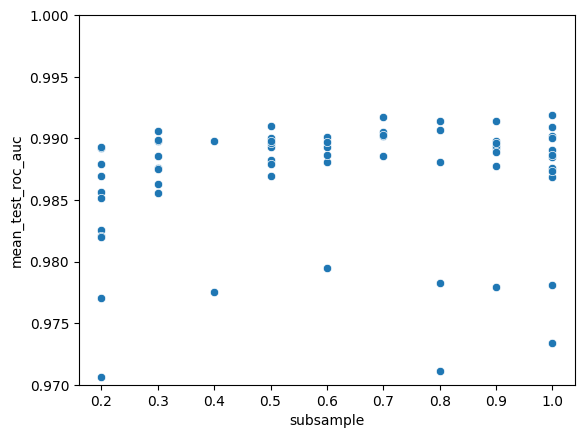

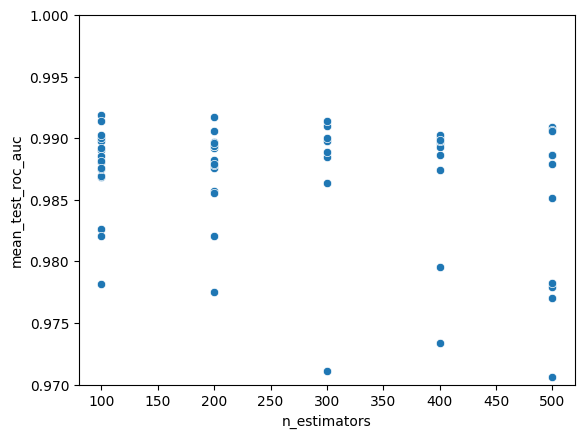

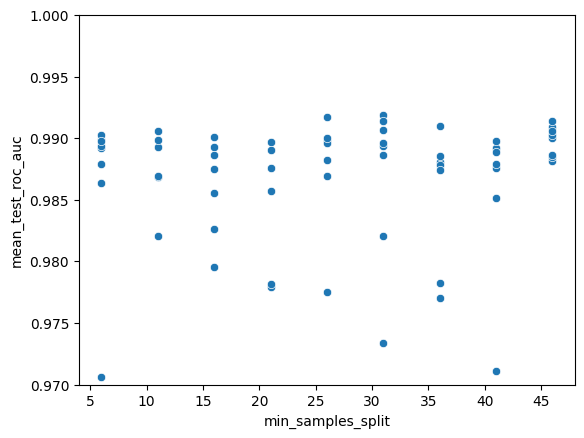

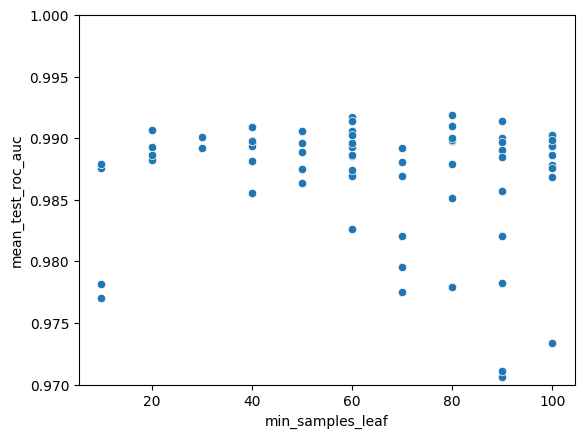

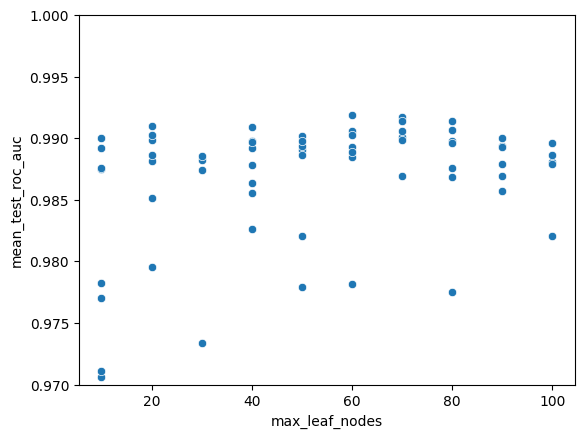

La columna 'max_features' contiene strings.


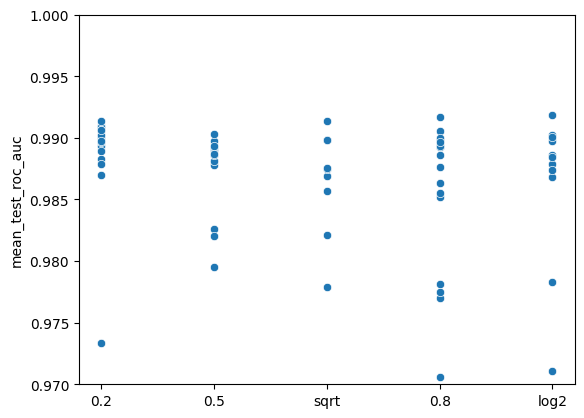

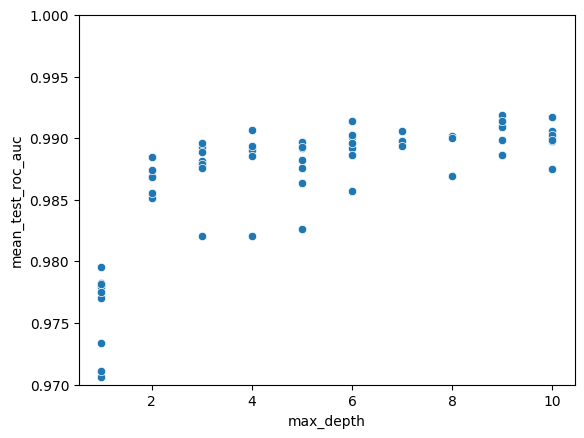

La columna 'loss' contiene strings.


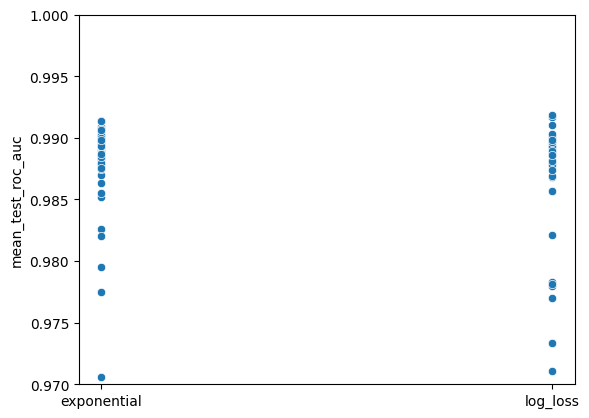

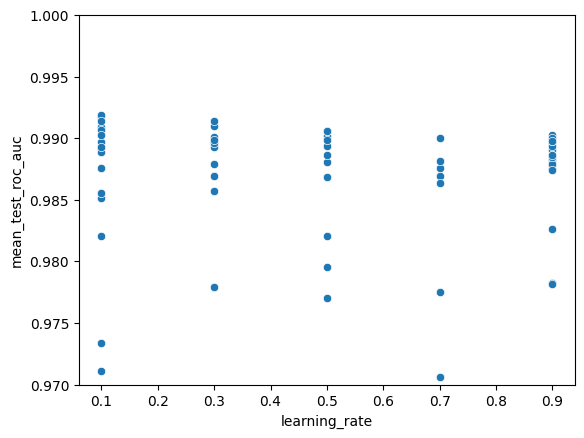

In [82]:
# Exploramos los mejores resultados para cada parámetro
for param in parametros:
  if guide[param].apply(lambda x: isinstance(x, str)).any():  # Comprobar si contiene strings
    print(f"La columna '{param}' contiene strings.")
    sns.scatterplot(x=[str(i) for i in guide[param]], y=guide['mean_test_roc_auc'])
  else:
    sns.scatterplot(data=guide, x=param, y='mean_test_roc_auc')
  plt.ylim([0.97, 1.0])
  plt.show()

De acuerdo al análisis gráfico de los resultados para cada parámetro, podemos considerar para la prueba de Grid Search los siguientes valores, dado que son los que parecen obtener en sus diferentes combinaciones los mejores resultados:



*   Sumbsample: Entre 0.4 y 0.7
*   n_estimators: 200
*   min_samples_split : Entre 25 y 35
*   min_samples_leaf: 60
*   max_features: sqrt
*   max_deph: Entre 6 y 9
*   max_leaf_nodes: Entre 40 y 60
*   loss: log_loss
*   learning_rate: 0.1

Por otra parte el parámetro de min_samples_leaf parece tener mucha variabilidad, así que no le pondremos restricciones y dejaremos el valor por defecto (1).




In [83]:
# Cremos el grid de parámetros según lo visto previamente
grid_params= {
    'loss': ['log_loss'],
    'n_estimators': [200],
    'learning_rate': [0.1],
    'max_leaf_nodes': [40, 50, 60],
    'max_depth': [6, 7, 8, 9],
    'min_samples_split': [25,30,35],
    'max_features': ['sqrt'],
    'min_samples_leaf': [40, 50, 60],
    'subsample': [0.6, 0.7, 0.8, 0.9]
}

#Inicializamos el GridSearch

grid_search = GridSearchCV(estimator,
                           grid_params,
                           cv = 5,
                           scoring = ['roc_auc', 'f1'],
                           refit ='roc_auc',
                           return_train_score = True)

In [84]:
grid_search.fit(X_train_red, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.1], 'loss': ['log_loss'],
                         'max_depth': [6, 7, 8, 9], 'max_features': ['sqrt'],
                         'max_leaf_nodes': [40, 50, 60],
                         'min_samples_leaf': [40, 50, 60],
                         'min_samples_split': [25, 30, 35],
                         'n_estimators': [200],
                         'subsample': [0.6, 0.7, 0.8, 0.9]},
             refit='roc_auc', return_train_score=True,
             scoring=['roc_auc', 'f1'])

In [85]:
# Obtenemos las predicciones para el conjunto de test
Y_pred3 = grid_search.predict(X_test_red)
Y_pred_p3 = grid_search.predict_proba(X_test_red)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train3 = grid_search.predict(X_train_red)
Y_pred_train_p3 = grid_search.predict_proba(X_train_red)[:,1]

<Figure size 1000x1000 with 0 Axes>

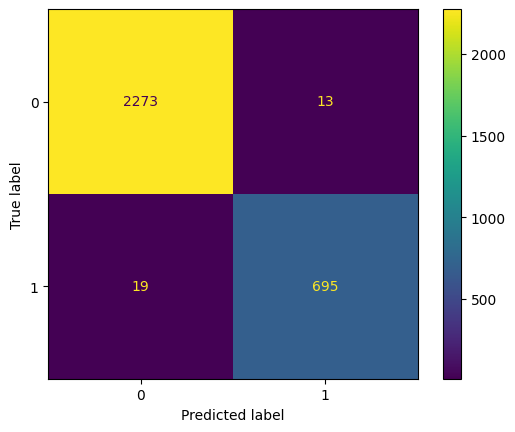

              precision    recall  f1-score   support

           0      0.992     0.994     0.993      2286
           1      0.982     0.973     0.977       714

    accuracy                          0.989      3000
   macro avg      0.987     0.984     0.985      3000
weighted avg      0.989     0.989     0.989      3000



In [86]:
# Evaluar la capacidad predictiva del modelo
cm_GS = confusion_matrix(y_test, Y_pred3)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_GS)
ax.plot()
plt.show()

report3 = classification_report(y_test, Y_pred3, digits = 3)
print(report3)

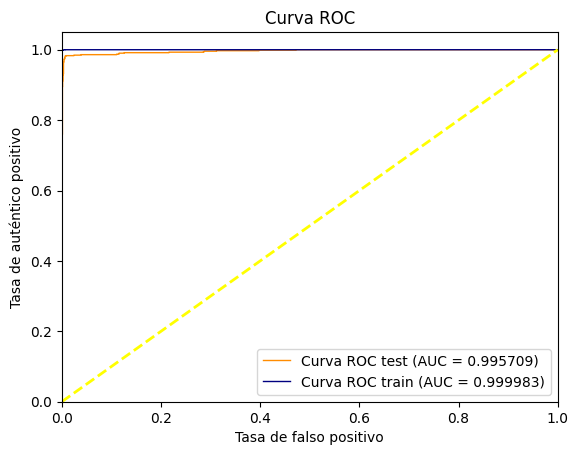

In [87]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test, AUC_train = plot_roc_curve(y_test, y_train, Y_pred_p3, Y_pred_train_p3, p=6)

In [88]:
#Realizamos un GridSearch empleando el método HistBoostClassifier para comparar tiempos
#Ajustamos los parámetros de acuerdo a la implementación del nuevo algoritmo
#Parametros lo más similar posible al GridSearch anterior

grid_params2= {
    'loss': ['log_loss'],
    'max_iter': [200],
    'learning_rate': [0.1],
    'max_leaf_nodes': [40, 50, 60],
    'max_depth': [6, 7, 8, 9],
    'min_samples_leaf': [25,30,35],
    'max_features': [np.sqrt(5)/5],
    'max_bins': [50, 100, 150, 200 ]
}

estimator2 = HistGradientBoostingClassifier(random_state= 42)

#Inicializamos el GridSearch
grid_search2 = GridSearchCV(estimator2,
                           grid_params2,
                           cv = 5,
                           scoring = ['roc_auc', 'f1'],
                           refit ='roc_auc',
                           return_train_score = True)

In [89]:
#Entrenamos el segundo modelo, comparamos tiempos de ejecución
grid_search2.fit(X_train_red, y_train)

GridSearchCV(cv=5, estimator=HistGradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.1], 'loss': ['log_loss'],
                         'max_bins': [50, 100, 150, 200],
                         'max_depth': [6, 7, 8, 9],
                         'max_features': [0.447213595499958], 'max_iter': [200],
                         'max_leaf_nodes': [40, 50, 60],
                         'min_samples_leaf': [25, 30, 35]},
             refit='roc_auc', return_train_score=True,
             scoring=['roc_auc', 'f1'])

In [90]:
# Obtenemos las predicciones para el conjunto de test
Y_pred4 = grid_search2.predict(X_test_red)
Y_pred_p4 = grid_search2.predict_proba(X_test_red)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train4 = grid_search2.predict(X_train_red)
Y_pred_train_p4 = grid_search2.predict_proba(X_train_red)[:,1]

<Figure size 1000x1000 with 0 Axes>

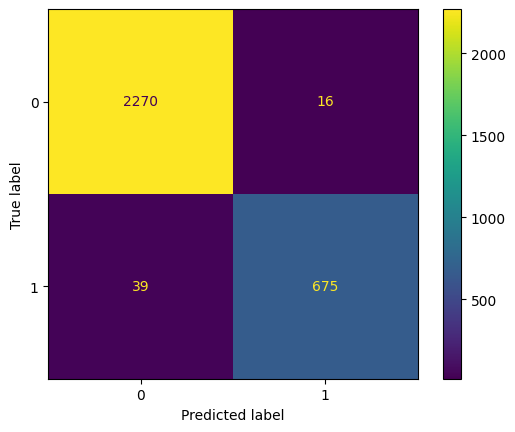

              precision    recall  f1-score   support

           0      0.983     0.993     0.988      2286
           1      0.977     0.945     0.961       714

    accuracy                          0.982      3000
   macro avg      0.980     0.969     0.974      3000
weighted avg      0.982     0.982     0.982      3000



In [91]:
# Evaluar la capacidad predictiva del modelo
cm_HGS = confusion_matrix(y_test, Y_pred4)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_HGS)
ax.plot()
plt.show()

report4 = classification_report(y_test, Y_pred4, digits = 3)
print(report4)

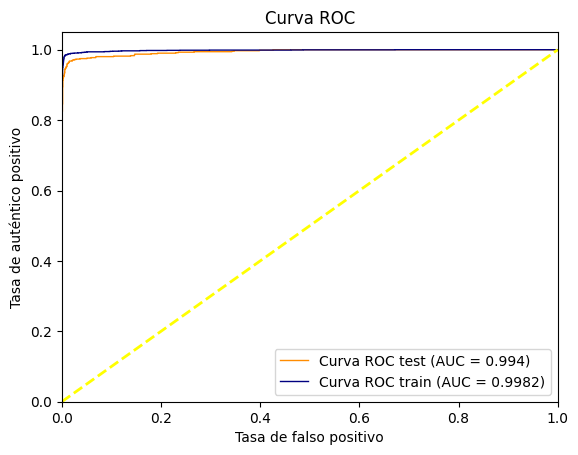

In [92]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test, AUC_train = plot_roc_curve(y_test, y_train, Y_pred_p4, Y_pred_train_p4, p=4)

## Evaluación del modelo optimizado

Como podemos ver, tras la aplicación del GridSearch el modelo de GradientBoosting Classifier que obtenemos nos devuelve unos resultados notablemente superiores al modelo anteriormente entrenado.

En el caso anterior obteníamos unos resultados de las métricas principales como siguen:

*   f1-score 1 = 0.952
*   f1-score 0 = 0.985
*   AUC test = 0.9908
*   AUC train = 0.9945

Mientras que ahora tenemos:

*   f1-score 1 = 0.994
*   f1-score 0 = 0.980
*   AUC test = 0.9957
*   AUC train = 0.9999

Además podemos apreciar en la matriz de confusión que tanto falsos positivos como falsos negativos se han reducido. Lo que sí que es cierto es que en este caso el GridSearch supone una gran carga computacional, tardando más de una hora en ejecutarse completamente. Para mejorar esto podríamos probar a emplear el otro método, el HistGradientBoost Classifier, que debería optimizar el tiempo de ejecución, aunque los parámetros de búsqueda son diferentes.

Realizando el mismo proceso de ajuste con GridSearch para el HistGradientBoost Classifier obtenemos unos resultados algo inferiores a los del modelo previo, que sí incorporaba un método de bootstraping. Esto se debe a que esta técnica al repetir parte de los datos las fasees de boosting está realizando una técnica de oversampling, que permite corregir el desbalance existente en las categorías de la variable objetivo.

Las métricas obtenidas con el métido de HistGradientBoosting son:

*   f1-score 1 = 0.988
*   f1-score 0 = 0.961
*   AUC test = 0.9940
*   AUC train = 0.9982

Que junto a la comparativa de la matriz de confusión evidencia que es un resultado mejor que el modelo original empleando el algoritmo de GradientBoost Classifier, y solo algo inferior a la optimización tras el uso del Gridsearch, pero con un tiempo de ejecución muy inferior (1h y 12 minutos para el GradientBoost vs 18 minutos para el HistGradientBoost en el ajuste del GridSearch).

## Parte opcional: Oversampling

Por simplicidad, vamos a implementar de forma independiente el classificador optimo obtenido a partir del GridSearch, y a partir de este modelo aplicaremos una técnica de oversampling para tratar de mejorar los resultados.

Este algoritmo por si mismo ya introduce un proceso de oversampling al especificar un subsample distinto de 1, puesto que durante el proceso de booststraping se repiten datos que pueden pertenecer al grupo infrarepresentado en la muestra de la variable objetivo.

Sin embargo ahora vamos a introducir una técnica de oversampling controlada de modo que igualemos la cantidad de casos mediante la repetición de datos existentes.



In [115]:
#Implementamos el código optimizado de manera independiente
Opt_GBC = GradientBoostingClassifier(max_depth=8,
                                     max_features='sqrt',
                                     max_leaf_nodes=40,
                                     min_samples_split=10,
                                     random_state=42,
                                     n_estimators=200,
                                     loss='log_loss',
                                     learning_rate=0.1,
                                     subsample= 1 #Para no tener un doble proceso de oversampling
                                     )

In [116]:
#Vamos a modificar los datos

#Importamos la función
from sklearn.utils import resample

# Creamos los nuevos conjuntos de datos
X_train_ov, y_train_ov = resample(X_train_red[y_train == 1],
                                  y_train[y_train == 1],
                                  n_samples=len(y_train[y_train == 1]),
                                  replace = True,
                                  random_state = 42)

# Unimos las partes
X_train_ov = np.concatenate((X_train_red[y_train == 0], X_train_ov))
y_train_ov = np.concatenate((y_train[y_train == 0], y_train_ov))

In [117]:
#Entrenamos el modelo con los valores resampleados
Opt_GBC.fit(X_train_ov, y_train_ov)

GradientBoostingClassifier(max_depth=8, max_features='sqrt', max_leaf_nodes=40,
                           min_samples_split=10, n_estimators=200,
                           random_state=42, subsample=1)

In [118]:
# Obtenemos las predicciones para el conjunto de test
Y_pred5 = Opt_GBC.predict(X_test_red)
Y_pred_p5 = Opt_GBC.predict_proba(X_test_red)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train5 = Opt_GBC.predict(X_train_red)
Y_pred_train_p5 = Opt_GBC.predict_proba(X_train_red)[:,1]

<Figure size 1000x1000 with 0 Axes>

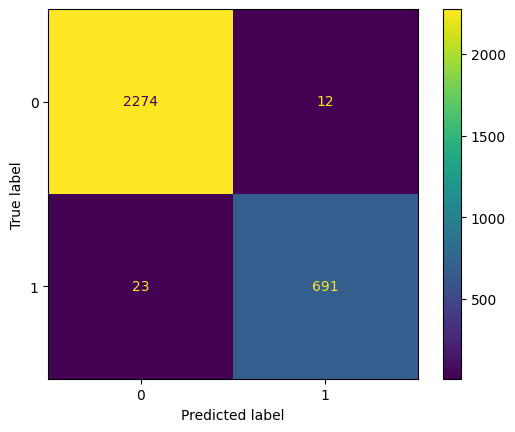

              precision    recall  f1-score   support

           0      0.990     0.995     0.992      2286
           1      0.983     0.968     0.975       714

    accuracy                          0.988      3000
   macro avg      0.986     0.981     0.984      3000
weighted avg      0.988     0.988     0.988      3000



In [119]:
# Evaluar la capacidad predictiva del modelo
cm_Over = confusion_matrix(y_test, Y_pred5)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_Over)
ax.plot()
plt.show()

report5 = classification_report(y_test, Y_pred5, digits = 3)
print(report5)

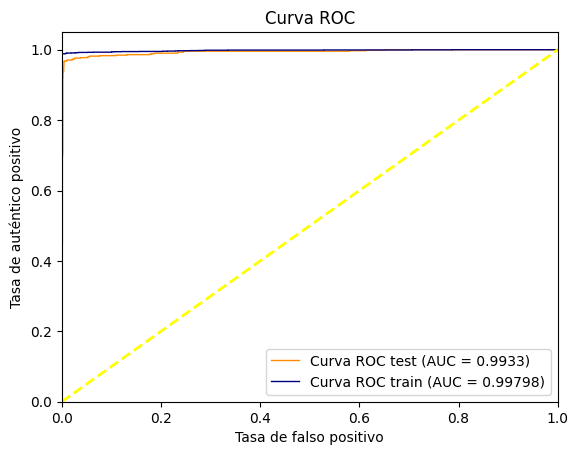

In [120]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test, AUC_train = plot_roc_curve(y_test, y_train, Y_pred_p5, Y_pred_train_p5, p=5)

Las métricas obtenidas con el métido de GradientBoostClassifier tras implementar el oversampling son:

*   f1-score 1 = 0.992
*   f1-score 0 = 0.975
*   AUC test = 0.9933
*   AUC train = 0.9980

Como vemos aquí los resultados empeoran ligeramente, lo que no quiere decir que el oversampling no sea útil. Pero como hemos visto, el uso del parámetro subsample ya introduce otro proceso de oversampling en el algoritmo anterior, que al parecer logra ajustar mejor el modelo.